# Shap tests using different datasets

In [2]:
import sys

!{sys.executable} -m pip install nbimporter

In [4]:
import numpy as np
import pandas as pd
import sklearn as skl
import zipfile as zf
import matplotlib.pyplot as plt
import nbimporter
import shap
import sklearn.ensemble
import xgboost as xgb

import Ft_Att_Rank as far

# Iris dataset

In [ ]:
import sklearn.datasets

iris= sklearn.datasets.load_iris()

X_iris= iris.data
Y_iris= iris.target

In [ ]:
# convert iris to a df and drop the setosa rows
df_iris= pd.DataFrame(data= np.c_[X_iris, Y_iris], columns= iris['feature_names'] + ['target'])
df_iris= df_iris[df_iris['target']!= 0].reset_index(drop= True)

In [ ]:
# split df_iris into features (x) and target (y)
df_iris_x= df_iris.loc[:,df_iris.columns[0:4]]
df_iris_y= df_iris.loc[:,df_iris.columns[4:5]]

df_iris_x.shape

In [ ]:
# visualizing the new dataset using PCA
from sklearn.decomposition import PCA

X_iris= df_iris_x.to_numpy()
Y_iris= np.concatenate(df_iris_y.to_numpy())

pca= PCA(n_components= 2)
X_pca= pca.fit(X_iris).transform(X_iris)

colors= ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_pca[Y_iris == i, 0], X_pca[Y_iris == i, 1], color=color, alpha=.8, lw=2, label=target_name)
    
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA - IRIS TWO CLASSES')
plt.figure()

In [ ]:
# ML model - Random forest

train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(df_iris_x,df_iris_y,train_size=0.80,random_state=1234)

rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

In [ ]:
# ML model - XGBoost random forest

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

In [ ]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Wine dataset

In [ ]:
wine= pd.read_csv('datasets/wine.data',header=None)

wine.columns= ['target','alcohol','malicAcid','ash','ashalcalinity','magnesium','totalPhenols','flavanoids','nonFlavanoidPhenols','proanthocyanins',
               'colorIntensity','hue','od280_od315','proline']

wine= wine[wine['target']!= 3].reset_index(drop= True)

x_wine= wine.iloc[:,1:len(wine.columns)].copy()
y_wine= np.asarray(wine['target'])

x_wine.shape

In [ ]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_wine,y_wine,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

In [ ]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Titanic dataset

In [4]:
# https://www.kaggle.com/c/titanic
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [6]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.8435754189944135

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


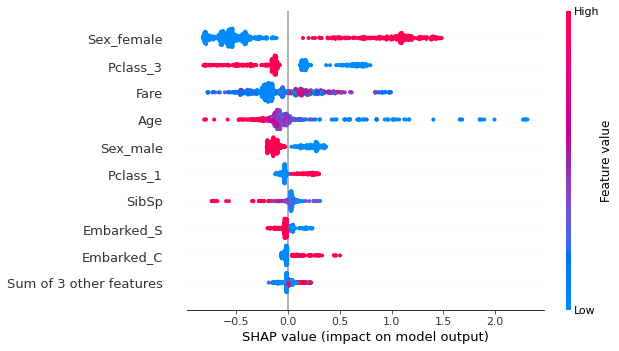

In [7]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

In [9]:
shap_values[0]

.values =
array([ 0.8572741 ,  0.17280906, -0.00398343, -0.0578672 , -0.01680603,
       -0.01836186, -0.12674566, -0.3050466 , -0.07537802,  0.32958537,
       -0.00528379,  0.04545538], dtype=float32)

.base_values =
-0.4703253

.data =
array([0.14551395, 0.125     , 0.        , 0.02194234, 0.        ,
       0.        , 1.        , 0.        , 1.        , 1.        ,
       0.        , 0.        ])

# Heartrisk dataset

In [ ]:
# https://www.kaggle.com/pritsheta/heart-attack
ds= zf.ZipFile('datasets/heart.zip')

heart_data= pd.read_csv(ds.open('heart.csv'))

x_heart= heart_data.iloc[:,:(len(heart_data.columns)-1)].copy()
y_heart= np.asarray(heart_data['target'])

x_heart.shape

In [ ]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_heart,y_heart,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

In [ ]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Breast cancer Wisconsin dataset

In [ ]:
# https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
wdbc= sklearn.datasets.load_breast_cancer()

X_wb_cancer= pd.DataFrame(wdbc.data,columns=wdbc.feature_names)
Y_wb_cancer= wdbc.target

X_wb_cancer.shape

In [ ]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(X_wb_cancer,Y_wb_cancer,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

In [ ]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Heart failure prediction dataset

In [ ]:
# https://www.kaggle.com/fedesoriano/heart-failure-prediction
ds= zf.ZipFile('datasets/heart_2.zip')

heart_2_data= pd.read_csv(ds.open('heart.csv'))

x_heart2= heart_2_data.iloc[:,:(len(heart_2_data.columns)-1)].copy()
y_heart2= np.asarray(heart_2_data['HeartDisease'])

x_heart2.shape

In [ ]:
numeric_columns= ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
categor_columns= list(filter(lambda x:x not in numeric_columns,x_heart2.columns))

Sex= [1 if s == 'M' else 0 for s in x_heart2['Sex']]
ExerciseAngina= [1 if e == 'Y' else 0 for e in x_heart2['ExerciseAngina']]

x_heart2['Sex']= Sex
x_heart2['ExerciseAngina']= ExerciseAngina

x_heart2_ohe= pd.get_dummies(x_heart2,columns=['ChestPainType','RestingECG','ST_Slope'])

x_heart2_ohe.shape

In [ ]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_heart2_ohe,y_heart2,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

In [ ]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Drug consumption dataset

In [ ]:
demographic_columns= ['Age','Gender','Education','Country','Ethnicity']
personality_columns= ['Neuroticism','Extraversion','Openness to experience','Agreeableness','Conscientiousness','Impulsiveness','Sensation seeking']

drugs_columns= ['Alcohol','Amphetamines','Amyl nitrite','Benzodiazepine','Caffeine','Cannabis','Chocolate','Cocaine','Crack','Ecstasy','Heroin','Ketamine',
    'Legal highs','Lysergic acid diethylamide','Methadone','Magic mushrooms','Nicotine','Fictitious drug Semeron','Volatile substance abuse']

drugs_legal= ['Alcohol', 'Caffeine', 'Chocolate', 'Nicotine']

feature_columns= demographic_columns + personality_columns

drugs_illegal= [drug for drug in drugs_columns if drug not in drugs_legal]

all_columns= feature_columns + drugs_columns

drugs_data= pd.read_csv('datasets/drug_consumption.data',names=["ID"]+all_columns).set_index("ID")

drugs_data.head()

# Arrhythmia dataset

In [ ]:
arrhy= pd.read_csv('datasets/arrhythmia.data',header=None)

arrhy